# Defect Detection - Exploration
Notebook for data exploration and model experiments.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [2]:
def load_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text
        bbox = obj.find("bndbox")
        objects.append({
            "name": name,
            "xmin": int(bbox.find("xmin").text),
            "ymin": int(bbox.find("ymin").text),
            "xmax": int(bbox.find("xmax").text),
            "ymax": int(bbox.find("ymax").text),
        })
    return objects


def show_image_with_boxes(image_path, xml_path):
    img = Image.open(image_path)
    objects = load_annotation(xml_path)

    fig, ax = plt.subplots(1)
    ax.imshow(img, cmap="gray")

    for obj in objects:
        x, y = obj["xmin"], obj["ymin"]
        w, h = obj["xmax"] - obj["xmin"], obj["ymax"] - obj["ymin"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 5, obj["name"], color="red", fontsize=8)

    ax.axis("off")
    plt.title(Path(image_path).name)
    plt.show()

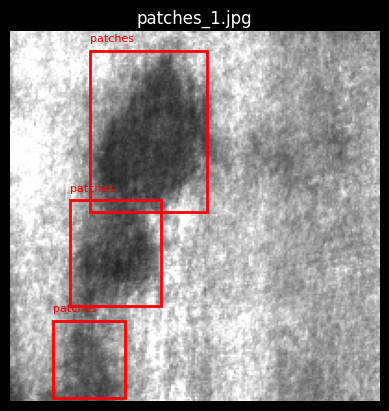

In [3]:
IMAGES_DIR = Path("../examples/images")
ANNOTATIONS_DIR = Path("../examples/annotations")

image_path = IMAGES_DIR / "patches_1.jpg"
xml_path = ANNOTATIONS_DIR / "patches_1.xml"

show_image_with_boxes(image_path, xml_path)

## Dataset class for Faster R-CNN

In [4]:
CLASSES = ["__background__", "crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}


class NEUDetDataset(Dataset):
    def __init__(self, images_dir, annotations_dir):
        self.images_dir = Path(images_dir)
        self.annotations_dir = Path(annotations_dir)
        self.image_files = sorted(self.images_dir.glob("*.jpg"))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        xml_path = self.annotations_dir / (image_path.stem + ".xml")

        img = Image.open(image_path).convert("RGB")
        img_tensor = F.to_tensor(img)

        objects = load_annotation(xml_path)
        boxes = [[o["xmin"], o["ymin"], o["xmax"], o["ymax"]] for o in objects]
        labels = [CLASS_TO_IDX[o["name"]] for o in objects]

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }

        return img_tensor, target

In [5]:
# Test dataset
dataset = NEUDetDataset("../data/IMAGES", "../data/ANNOTATIONS")
print(f"Dataset size: {len(dataset)}")

img_tensor, target = dataset[10]
print(f"Image shape: {img_tensor.shape}")
print(f"Boxes: {target['boxes']}")
print(f"Labels: {target['labels']}")

Dataset size: 1800
Image shape: torch.Size([3, 200, 200])
Boxes: tensor([[  3.,  21.,  69., 149.],
        [ 90., 115., 198., 193.]])
Labels: tensor([1, 1])


## Inference - loading model and weights

In [6]:
# Model was trained on Kaggle:
# https://www.kaggle.com/code/sawickipiotr/defect-detection-faster-r-cnn-training

# Load model with weights
WEIGHTS_PATH = "../data/weights.pth"

model_inf = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features = model_inf.roi_heads.box_predictor.cls_score.in_features
model_inf.roi_heads.box_predictor = FastRCNNPredictor(in_features, len(CLASSES))

model_inf.load_state_dict(torch.load(WEIGHTS_PATH, map_location="cpu"))
model_inf.eval()
print("Model loaded.")

Model loaded.


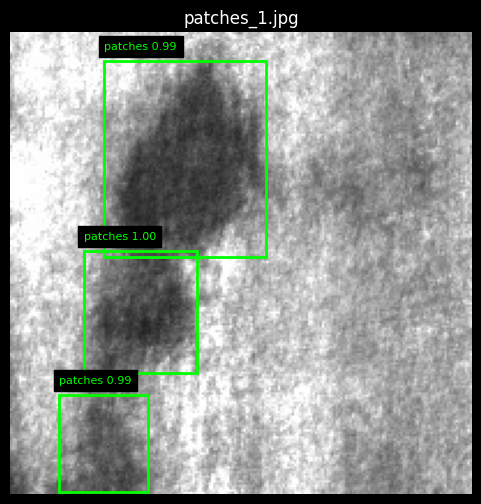

Detected 3 defect(s).


In [7]:
SCORE_THRESHOLD = 0.5

def predict_and_show(image_path, threshold=SCORE_THRESHOLD):
    img = Image.open(image_path).convert("RGB")
    img_tensor = F.to_tensor(img)

    with torch.no_grad():
        outputs = model_inf([img_tensor])[0]

    boxes = outputs["boxes"]
    labels = outputs["labels"]
    scores = outputs["scores"]

    # filter by confidence threshold
    keep = scores >= threshold
    boxes, labels, scores = boxes[keep], labels[keep], scores[keep]

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img, cmap="gray")

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{CLASSES[label]} {score:.2f}",
                color="lime", fontsize=8, backgroundcolor="black")

    ax.axis("off")
    plt.title(Path(image_path).name)
    plt.show()
    print(f"Detected {len(boxes)} defect(s).")

# Test on a sample image
predict_and_show("../examples/images/patches_1.jpg")

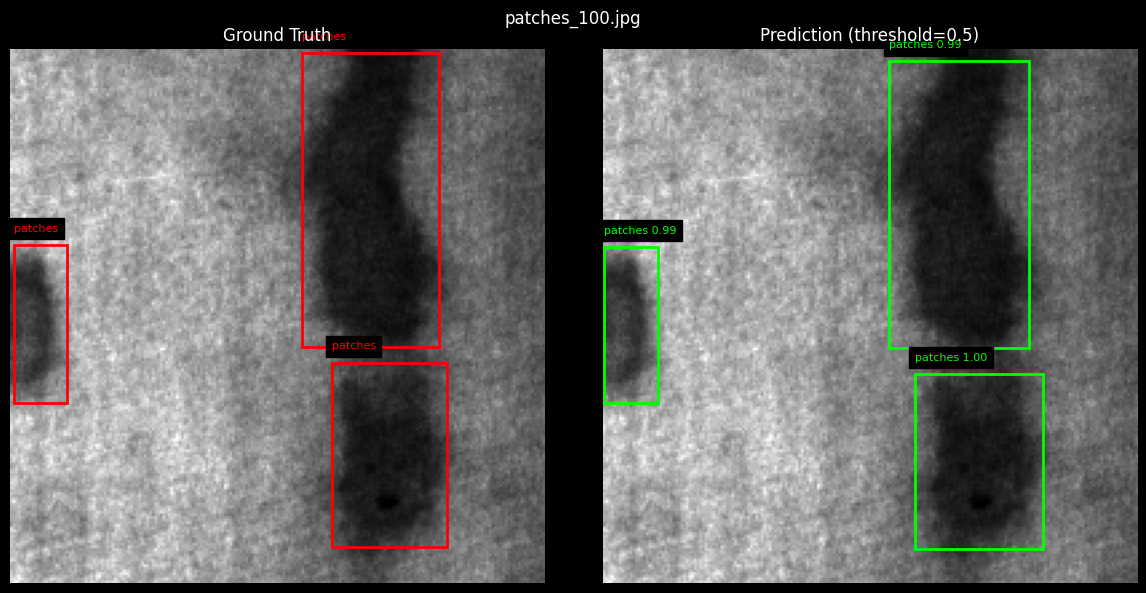

In [9]:
def predict_vs_gt(image_path, xml_path, threshold=SCORE_THRESHOLD):
    img = Image.open(image_path).convert("RGB")
    img_tensor = F.to_tensor(img)

    with torch.no_grad():
        outputs = model_inf([img_tensor])[0]

    boxes_pred = outputs["boxes"]
    labels_pred = outputs["labels"]
    scores_pred = outputs["scores"]
    keep = scores_pred >= threshold
    boxes_pred, labels_pred, scores_pred = boxes_pred[keep], labels_pred[keep], scores_pred[keep]

    gt_objects = load_annotation(xml_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # --- Ground Truth ---
    ax1.imshow(img, cmap="gray")
    for obj in gt_objects:
        x, y = obj["xmin"], obj["ymin"]
        w, h = obj["xmax"] - obj["xmin"], obj["ymax"] - obj["ymin"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax1.add_patch(rect)
        ax1.text(x, y - 5, obj["name"], color="red", fontsize=8, backgroundcolor="black")
    ax1.set_title("Ground Truth")
    ax1.axis("off")

    # --- Prediction ---
    ax2.imshow(img, cmap="gray")
    for box, label, score in zip(boxes_pred, labels_pred, scores_pred):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax2.add_patch(rect)
        ax2.text(x1, y1 - 5, f"{CLASSES[label]} {score:.2f}",
                 color="lime", fontsize=8, backgroundcolor="black")
    ax2.set_title(f"Prediction (threshold={threshold})")
    ax2.axis("off")

    plt.suptitle(Path(image_path).name)
    plt.tight_layout()
    plt.show()

# Test
predict_vs_gt(
    "../examples/images/patches_100.jpg",
    "../examples/annotations/patches_100.xml"
)